2.1理论计算题

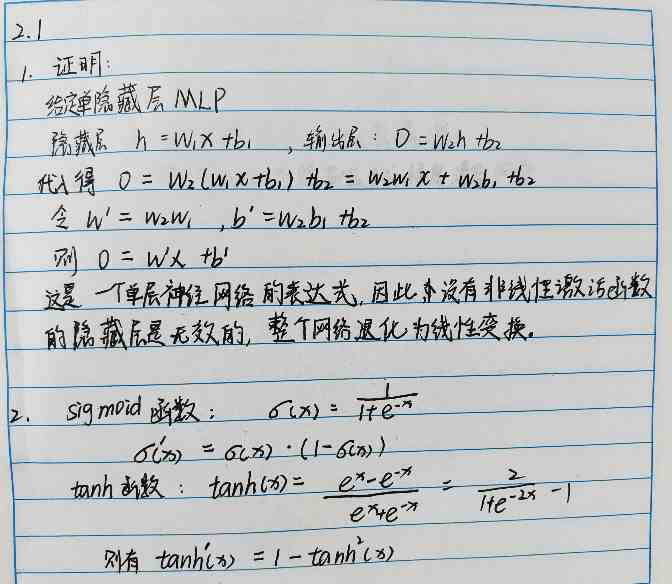

In [3]:
# 2.2编程题
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

100%|██████████| 29.5k/29.5k [00:00<00:00, 130kB/s]
100%|██████████| 4.42M/4.42M [01:20<00:00, 55.3kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.23MB/s]


Epoch 1: Loss=0.7056, Acc=0.8219
Epoch 2: Loss=0.4510, Acc=0.8324
Epoch 3: Loss=0.4019, Acc=0.8458
Epoch 4: Loss=0.3752, Acc=0.8510
Epoch 5: Loss=0.3554, Acc=0.8501


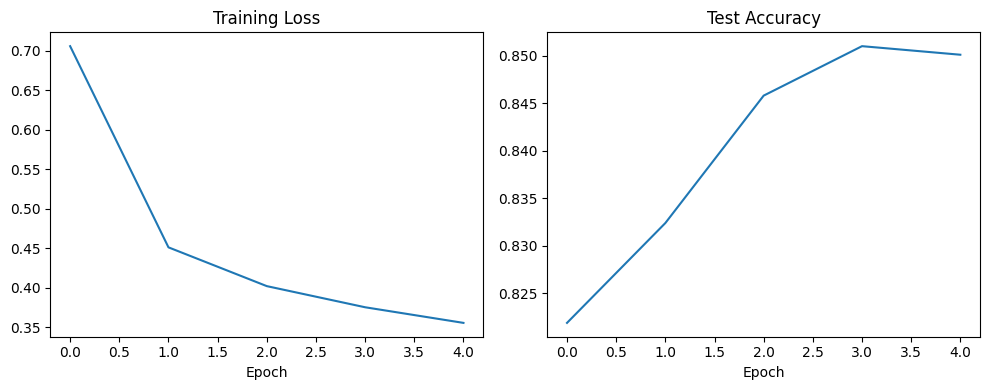


最终测试准确率: 0.8501


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)

# 加载Fashion-MNIST（只取部分数据加速）
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 只用前2000个训练样本和500个测试样本
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 参数初始化
input_size, hidden_size, output_size = 784, 128, 10
W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)
W1.requires_grad_(True); b1.requires_grad_(True)
W2.requires_grad_(True); b2.requires_grad_(True)

# ReLU和Softmax交叉熵
def relu(x): return torch.maximum(torch.tensor(0.0), x)

def cross_entropy_loss(logits, labels):
    exp_logits = torch.exp(logits - logits.max(dim=1, keepdim=True)[0])
    probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    return -torch.log(probs[range(len(labels)), labels] + 1e-8).mean()

# 训练
lr, epochs = 0.1, 5
train_losses, test_accs = [], []

for epoch in range(epochs):
    total_loss = 0
    for x, y in train_loader:
        h = relu(x @ W1 + b1)
        logits = h @ W2 + b2
        loss = cross_entropy_loss(logits, y)
        
        loss.backward()
        with torch.no_grad():
            W1 -= lr * W1.grad; b1 -= lr * b1.grad
            W2 -= lr * W2.grad; b2 -= lr * b2.grad
        W1.grad.zero_(); b1.grad.zero_(); W2.grad.zero_(); b2.grad.zero_()
        
        total_loss += loss.item()
    
    # 测试
    correct = sum((torch.argmax(relu(x @ W1 + b1) @ W2 + b2, dim=1) == y).sum().item() for x, y in test_loader)
    acc = correct / len(test_dataset)
    train_losses.append(total_loss / len(train_loader))
    test_accs.append(acc)
    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Acc={acc:.4f}")

# 绘图
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(train_losses); plt.title('Training Loss'); plt.xlabel('Epoch')
plt.subplot(1,2,2); plt.plot(test_accs); plt.title('Test Accuracy'); plt.xlabel('Epoch')
plt.tight_layout();  plt.show()
print(f"\n最终测试准确率: {test_accs[-1]:.4f}")

3.1 理论计算题

1.过拟合与欠拟合
训练误差与泛化误差的区别：
训练误差：模型在训练数据上的误差，反映模型对训练集的拟合程度。
泛化误差：模型在未见过的测试数据上的误差，反映模型的预测能力。
当训练误差极低但泛化误差很高时，模型处于过拟合状态。
缓解过拟合的方法：
减少模型复杂度（减少层数、神经元数量）;增加训练数据量或数据增强;使用正则化技术（L1/L2正则化、Dropout）

2.K折交叉验证
算法步骤：
将数据集随机划分为K个大小相等的子集；
对于每个𝑖=1,2,...,𝐾：
使用第i个子集作为验证集，使用其余K-1个子集作为训练集，训练模型并计算验证集上的性能指标；
计算K次验证结果的平均值作为最终评估指标；
使用全部数据重新训练最终模型。

In [ ]:
# 3.2编程题
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split


=== 无正则化训练 ===
Epoch 20: Train Loss=0.4483, Val Loss=1.6839
Epoch 40: Train Loss=0.3228, Val Loss=1.5842
Epoch 60: Train Loss=0.0754, Val Loss=1.5371
Epoch 80: Train Loss=0.0359, Val Loss=1.5271
Epoch 100: Train Loss=0.0225, Val Loss=1.5147

=== 权重衰减训练 (L2) ===
Epoch 20: Train Loss=0.6195, Val Loss=1.7345
Epoch 40: Train Loss=0.2075, Val Loss=1.5641
Epoch 60: Train Loss=0.1370, Val Loss=1.5331
Epoch 80: Train Loss=0.0424, Val Loss=1.5519
Epoch 100: Train Loss=0.0286, Val Loss=1.5660

=== Dropout训练 ===
Epoch 20: Train Loss=2.5148, Val Loss=1.1510
Epoch 40: Train Loss=1.7219, Val Loss=1.1091
Epoch 60: Train Loss=2.5802, Val Loss=1.0451
Epoch 80: Train Loss=1.7364, Val Loss=1.0440
Epoch 100: Train Loss=0.9035, Val Loss=1.0853


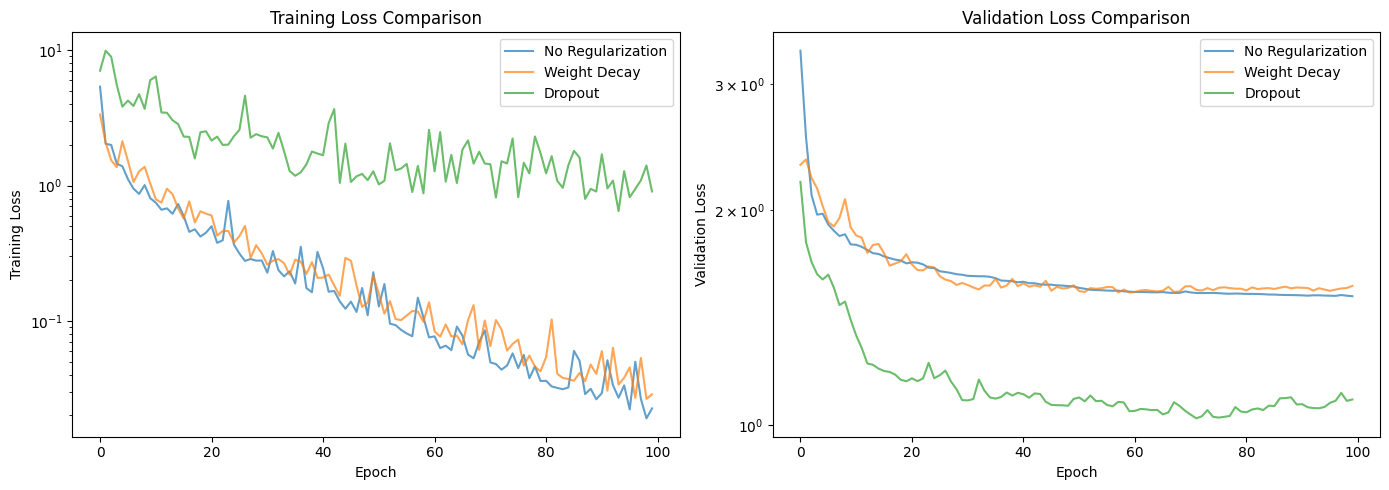


=== 最终结果对比 ===
无正则化 - 最终训练损失: 0.022523, 验证损失: 1.514679
权重衰减 - 最终训练损失: 0.028604, 验证损失: 1.565989
Dropout - 最终训练损失: 0.903529, 验证损失: 1.085344


In [ ]:
torch.manual_seed(42)
np.random.seed(42)

# 生成高维多项式拟合数据（模拟过拟合场景）
def generate_polynomial_data(n_samples=200, n_features=100, degree=5, noise=0.1):
    X = np.random.randn(n_samples, n_features)
    # 真实权重只有前degree+1个非零
    true_w = np.zeros(n_features)
    for i in range(degree + 1):
        true_w[i] = 1.0 / (i + 1)
    y = X @ true_w + noise * np.random.randn(n_samples)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# 使用少量训练样本来制造过拟合
X_train, y_train = generate_polynomial_data(n_samples=50, n_features=50)
X_val, y_val = generate_polynomial_data(n_samples=100, n_features=50)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Dropout实现
def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return X * mask / (1 - dropout)

class MLPWithRegularization:
    def __init__(self, input_dim, hidden_dims=[128, 64], output_dim=1, dropout_rate=0.5):
        self.params = {}
        self.dropout_rate = dropout_rate
        
        # 初始化参数
        prev_dim = input_dim
        for i, h_dim in enumerate(hidden_dims):
            self.params[f'W{i+1}'] = torch.randn(prev_dim, h_dim) * np.sqrt(2.0 / prev_dim)
            self.params[f'b{i+1}'] = torch.zeros(h_dim)
            prev_dim = h_dim
        self.params[f'W{len(hidden_dims)+1}'] = torch.randn(prev_dim, output_dim) * np.sqrt(2.0 / prev_dim)
        self.params[f'b{len(hidden_dims)+1}'] = torch.zeros(output_dim)
        
        # 启用梯度
        for param in self.params.values():
            param.requires_grad_(True)
    
    def forward(self, X, is_training=True):
        h = X
        num_layers = len(self.params) // 2
        for i in range(num_layers - 1):
            h = h @ self.params[f'W{i+1}'] + self.params[f'b{i+1}']
            h = torch.relu(h)
            if is_training:
                h = dropout_layer(h, self.dropout_rate, is_training)
        output = h @ self.params[f'W{num_layers}'] + self.params[f'b{num_layers}']
        return output
    
    def zero_grad(self):
        for param in self.params.values():
            if param.grad is not None:
                param.grad.zero_()
    
    def sgd_step(self, lr, weight_decay=0.0):
        with torch.no_grad():
            for param in self.params.values():
                if weight_decay > 0:
                    param -= lr * (param.grad + weight_decay * param)
                else:
                    param -= lr * param.grad
                param.grad.zero_()

def mse_loss(pred, target):
    return ((pred - target) ** 2).mean()

def train_with_regularization(model, train_loader, val_loader, epochs=100, lr=0.001, weight_decay=0.0, use_dropout=False):
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # 训练
        model.zero_grad()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            pred = model.forward(X_batch, is_training=use_dropout)
            loss = mse_loss(pred, y_batch)
            loss.backward()
            model.sgd_step(lr, weight_decay)
            epoch_loss += loss.item()
        
        train_losses.append(epoch_loss / len(train_loader))
        
        # 验证
        with torch.no_grad():
            val_loss = 0
            for X_batch, y_batch in val_loader:
                pred = model.forward(X_batch, is_training=False)
                val_loss += mse_loss(pred, y_batch).item()
            val_losses.append(val_loss / len(val_loader))
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}")
    
    return train_losses, val_losses

input_dim = 50
hidden_dims = [128, 64]

# 实验1：无正则化
model_no_reg = MLPWithRegularization(input_dim, hidden_dims, dropout_rate=0.0)
print("\n=== 无正则化训练 ===")
train_losses_no_reg, val_losses_no_reg = train_with_regularization(
    model_no_reg, train_loader, val_loader, epochs=100, lr=0.001, weight_decay=0.0, use_dropout=False
)

# 实验2：权重衰减（L2正则化）
model_wd = MLPWithRegularization(input_dim, hidden_dims, dropout_rate=0.0)
print("\n=== 权重衰减训练 (L2) ===")
train_losses_wd, val_losses_wd = train_with_regularization(
    model_wd, train_loader, val_loader, epochs=100, lr=0.001, weight_decay=0.01, use_dropout=False
)

# 实验3：Dropout
model_dropout = MLPWithRegularization(input_dim, hidden_dims, dropout_rate=0.5)
print("\n=== Dropout训练 ===")
train_losses_dropout, val_losses_dropout = train_with_regularization(
    model_dropout, train_loader, val_loader, epochs=100, lr=0.001, weight_decay=0.0, use_dropout=True
)

# 绘制对比曲线
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_no_reg, label='No Regularization', alpha=0.7)
plt.plot(train_losses_wd, label='Weight Decay', alpha=0.7)
plt.plot(train_losses_dropout, label='Dropout', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.plot(val_losses_no_reg, label='No Regularization', alpha=0.7)
plt.plot(val_losses_wd, label='Weight Decay', alpha=0.7)
plt.plot(val_losses_dropout, label='Dropout', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.yscale('log')

plt.tight_layout()
plt.show()

print("\n=== 最终结果对比 ===")
print(f"无正则化 - 最终训练损失: {train_losses_no_reg[-1]:.6f}, 验证损失: {val_losses_no_reg[-1]:.6f}")
print(f"权重衰减 - 最终训练损失: {train_losses_wd[-1]:.6f}, 验证损失: {val_losses_wd[-1]:.6f}")
print(f"Dropout - 最终训练损失: {train_losses_dropout[-1]:.6f}, 验证损失: {val_losses_dropout[-1]:.6f}")

4.1理论计算题

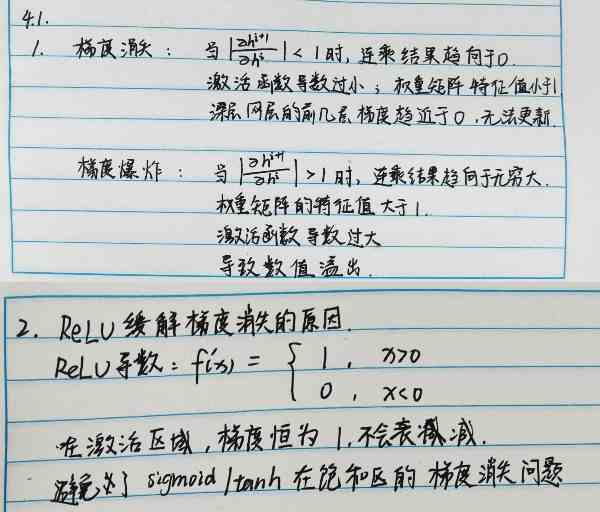

In [10]:
#4.2编程题
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

实验1: Sigmoid + 标准初始化 (均值0，标准差1)
梯度范数范围: [1.54e+03, 3.50e+04]
第一层梯度范数: 3.50e+04
最后一层梯度范数: 1.67e+03

实验2: ReLU + 大标准差初始化 (std=10)
梯度范数范围: [nan, nan]
警告: 检测到NaN - 梯度爆炸!

实验3: Xavier初始化 + ReLU
梯度范数范围: [1.70e+00, 7.24e+00]
第一层梯度范数: 1.70e+00
最后一层梯度范数: 6.31e+00

实验4: Xavier初始化 + LeakyReLU
梯度范数范围: [1.47e+00, 8.03e+00]


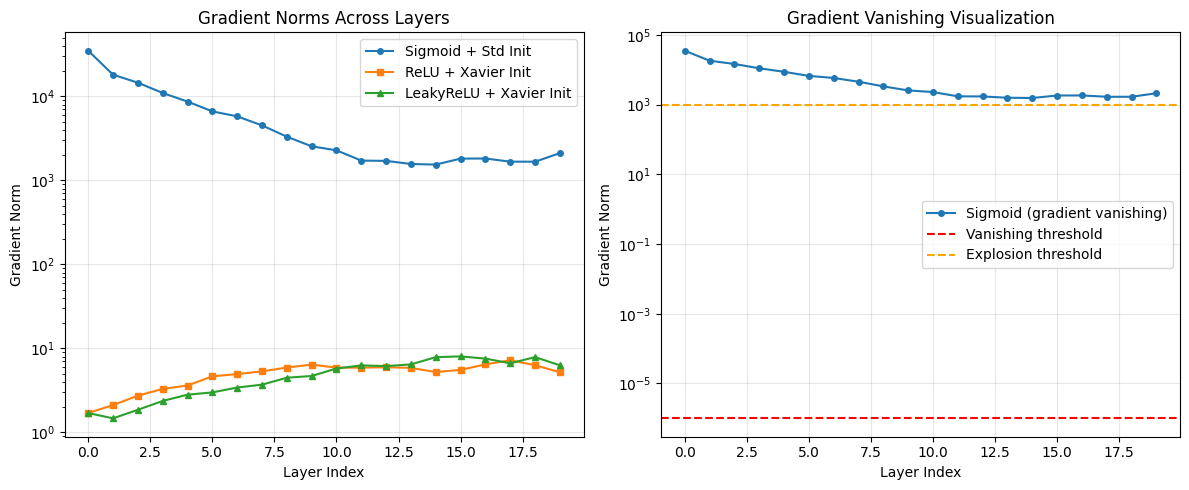


=== 结论 ===
1. Sigmoid + 标准初始化: 深层梯度消失，浅层几乎无法更新
2. ReLU + 大标准差: 梯度爆炸，数值不稳定
3. Xavier + ReLU/LeakyReLU: 梯度稳定在合理区间


In [ ]:
# 构建深层网络
class DeepNetwork(nn.Module):
    def __init__(self, n_layers=20, hidden_dim=256, input_dim=784, output_dim=10, activation='sigmoid'):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, hidden_dim))
        
        for _ in range(n_layers - 2):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
        
        self.layers.append(nn.Linear(hidden_dim, output_dim))
        
        # 设置激活函数
        if activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.01)
    
    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = self.activation(layer(x))
        x = self.layers[-1](x)  # 最后一层无激活
        return x

def compute_gradient_norms(model, x, y):
    """计算各层参数的梯度范数"""
    model.zero_grad()
    output = model(x)
    loss = output.sum()
    loss.backward()
    
    norms = []
    for i, layer in enumerate(model.layers):
        if hasattr(layer, 'weight') and layer.weight.grad is not None:
            norms.append(torch.norm(layer.weight.grad).item())
        else:
            norms.append(0)
    return norms

# 生成随机数据
batch_size = 64
input_dim = 784
x_random = torch.randn(batch_size, input_dim)
y_random = torch.randint(0, 10, (batch_size,))

# 实验1：Sigmoid + 标准初始化（梯度消失）
print("=" * 50)
print("实验1: Sigmoid + 标准初始化 (均值0，标准差1)")
model_sigmoid = DeepNetwork(activation='sigmoid')

# 使用标准正态分布初始化
def std_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1)
        nn.init.zeros_(m.bias)

model_sigmoid.apply(std_init)
norms_sigmoid = compute_gradient_norms(model_sigmoid, x_random, y_random)
print(f"梯度范数范围: [{min(norms_sigmoid):.2e}, {max(norms_sigmoid):.2e}]")
print(f"第一层梯度范数: {norms_sigmoid[0]:.2e}")
print(f"最后一层梯度范数: {norms_sigmoid[-2]:.2e}")

# 实验2：ReLU + 大标准差初始化（梯度爆炸）
print("\n" + "=" * 50)
print("实验2: ReLU + 大标准差初始化 (std=10)")
model_relu_large = DeepNetwork(activation='relu')

def large_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10)
        nn.init.zeros_(m.bias)

try:
    model_relu_large.apply(large_init)
    norms_relu_large = compute_gradient_norms(model_relu_large, x_random, y_random)
    print(f"梯度范数范围: [{min(norms_relu_large):.2e}, {max(norms_relu_large):.2e}]")
    if torch.isnan(torch.tensor(norms_relu_large)).any():
        print("警告: 检测到NaN - 梯度爆炸!")
except Exception as e:
    print(f"数值溢出: {e}")

# 实验3：Xavier初始化 + ReLU（稳定）
print("\n" + "=" * 50)
print("实验3: Xavier初始化 + ReLU")
model_xavier_relu = DeepNetwork(activation='relu')

def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

model_xavier_relu.apply(xavier_init)
norms_xavier_relu = compute_gradient_norms(model_xavier_relu, x_random, y_random)
print(f"梯度范数范围: [{min(norms_xavier_relu):.2e}, {max(norms_xavier_relu):.2e}]")
print(f"第一层梯度范数: {norms_xavier_relu[0]:.2e}")
print(f"最后一层梯度范数: {norms_xavier_relu[-2]:.2e}")

# 实验4：Xavier初始化 + LeakyReLU
print("\n" + "=" * 50)
print("实验4: Xavier初始化 + LeakyReLU")
model_xavier_leaky = DeepNetwork(activation='leaky_relu')
model_xavier_leaky.apply(xavier_init)
norms_xavier_leaky = compute_gradient_norms(model_xavier_leaky, x_random, y_random)
print(f"梯度范数范围: [{min(norms_xavier_leaky):.2e}, {max(norms_xavier_leaky):.2e}]")

# 可视化各层梯度分布
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
layer_indices = range(len(norms_sigmoid))
plt.plot(layer_indices, norms_sigmoid, 'o-', label='Sigmoid + Std Init', markersize=4)
plt.plot(layer_indices, norms_xavier_relu, 's-', label='ReLU + Xavier Init', markersize=4)
plt.plot(layer_indices, norms_xavier_leaky, '^-', label='LeakyReLU + Xavier Init', markersize=4)
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norms Across Layers')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
layer_indices = range(len(norms_sigmoid))
plt.plot(layer_indices, norms_sigmoid, 'o-', label='Sigmoid (gradient vanishing)', markersize=4)
plt.axhline(y=1e-6, color='r', linestyle='--', label='Vanishing threshold')
plt.axhline(y=1e3, color='orange', linestyle='--', label='Explosion threshold')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm')
plt.title('Gradient Vanishing Visualization')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== 结论 ===")
print("1. Sigmoid + 标准初始化: 深层梯度消失，浅层几乎无法更新")
print("2. ReLU + 大标准差: 梯度爆炸，数值不稳定")
print("3. Xavier + ReLU/LeakyReLU: 梯度稳定在合理区间")

5.1 理论计算题

协变量偏移与标签偏移
1.协变量偏移，定义：输入分布发生变化，但条件标签分布不变。
例子：医学诊断中，训练数据来自城市医院（年轻人群），测试数据来自乡村医院（老年人群）
影响：模型在新数据分布上表现下降
2.标签偏移，定义：标签分布发生变化，但类条件输入分布不变。
例子：电商推荐中，季节性商品比例变化（冬季羽绒服变多）
影响：需要根据先验概率调整预测

区别与联系：
区别：偏移发生的变量不同（输入vs标签）
联系：都违反了独立同分布假设，需要通过重要性加权或领域自适应来校正

In [12]:
#5.2编程题
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

=== 数据集统计 ===
训练集 X 均值: -0.981, 标准差: 0.979
测试集 X 均值: 1.988, 标准差: 0.959

=== 基线模型训练 ===
训练集 MSE: 0.009923
测试集 MSE: 0.010182

=== 计算重要性权重 ===
权重统计: min=0.000, max=653.521, mean=1.000

=== 加权模型训练 ===
训练集 MSE: 0.057507
测试集 MSE: 0.024020


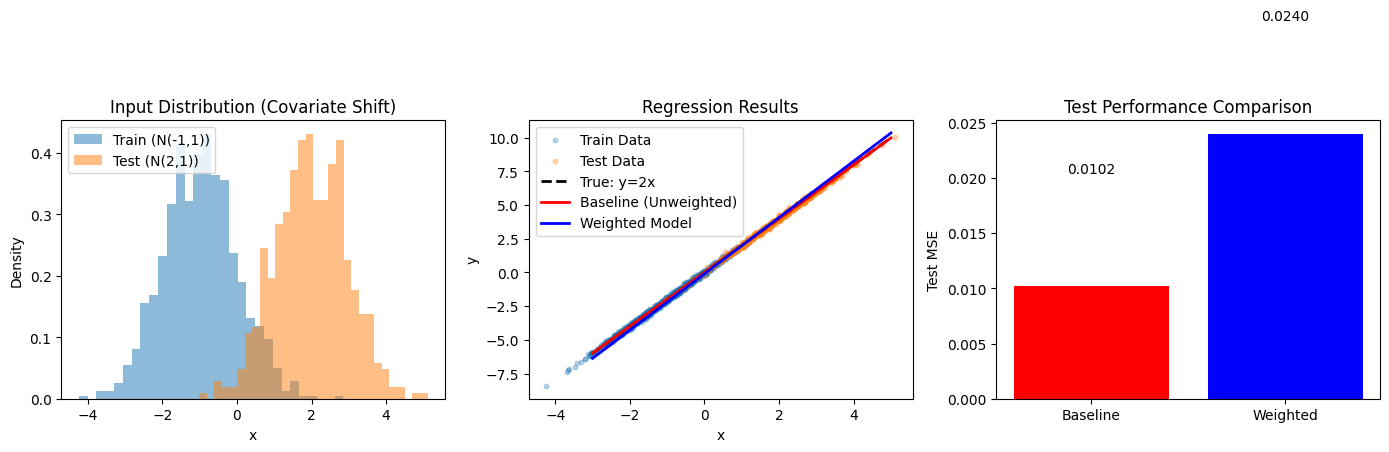


=== 最终结果 ===
测试集 MSE - 基线模型: 0.010182
测试集 MSE - 加权模型: 0.024020
改善幅度: -135.90%


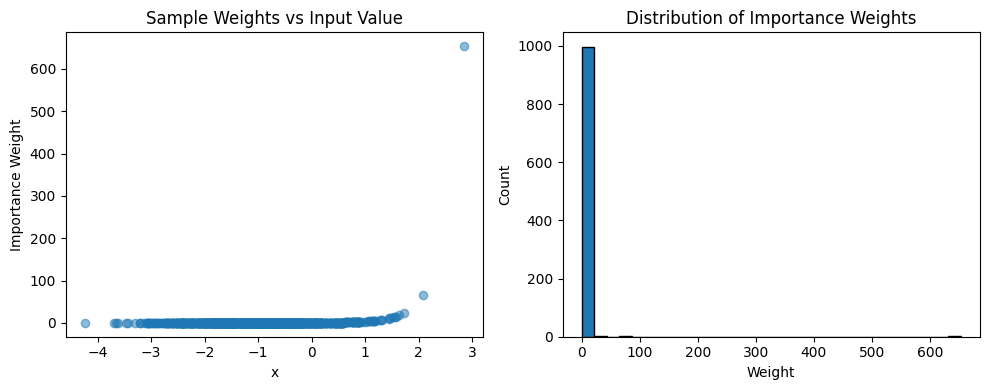

In [ ]:

torch.manual_seed(42)
np.random.seed(42)

# 1. 构造数据集
def generate_datasets():
    # 训练集 P: x ~ N(-1, 1), y = 2x + epsilon
    n_train = 1000
    n_test = 500
    
    X_train = np.random.normal(-1, 1, n_train).reshape(-1, 1)
    epsilon = np.random.normal(0, 0.1, n_train)
    y_train = 2 * X_train.flatten() + epsilon
    
    # 测试集 Q: x ~ N(2, 1)
    X_test = np.random.normal(2, 1, n_test).reshape(-1, 1)
    epsilon_test = np.random.normal(0, 0.1, n_test)
    y_test = 2 * X_test.flatten() + epsilon_test
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = generate_datasets()

print("=== 数据集统计 ===")
print(f"训练集 X 均值: {X_train.mean():.3f}, 标准差: {X_train.std():.3f}")
print(f"测试集 X 均值: {X_test.mean():.3f}, 标准差: {X_test.std():.3f}")

# 2. 基线模型：线性回归
class LinearRegression:
    def __init__(self):
        self.w = None
        self.b = None
    
    def fit(self, X, y, sample_weight=None):
        X_with_bias = np.c_[X, np.ones(len(X))]
        if sample_weight is not None:
            # 加权最小二乘法
            W = np.diag(sample_weight)
            theta = np.linalg.inv(X_with_bias.T @ W @ X_with_bias) @ X_with_bias.T @ W @ y
        else:
            theta = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
        self.w = theta[0]
        self.b = theta[1]
    
    def predict(self, X):
        return self.w * X.flatten() + self.b
    
    def mse(self, X, y):
        pred = self.predict(X)
        return np.mean((pred - y) ** 2)

# 3. 训练基线模型
print("\n=== 基线模型训练 ===")
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
train_mse_baseline = baseline_model.mse(X_train, y_train)
test_mse_baseline = baseline_model.mse(X_test, y_test)
print(f"训练集 MSE: {train_mse_baseline:.6f}")
print(f"测试集 MSE: {test_mse_baseline:.6f}")

# 4. 训练逻辑回归分类器计算重要性权重
def compute_importance_weights(X_train, X_test):
    """使用逻辑回归计算P(test|x)/P(train|x)的近似比例"""
    n_train = len(X_train)
    n_test = len(X_test)
    
    # 合并数据
    X_combined = np.vstack([X_train, X_test])
    y_combined = np.array([0] * n_train + [1] * n_test)  # 0: train, 1: test
    
    # 训练逻辑回归
    clf = LogisticRegression()
    clf.fit(X_combined, y_combined)
    
    # 计算P(test|x) = P(y=1|x)
    P_test = clf.predict_proba(X_train)[:, 1]
    P_train = 1 - P_test
    
    # 权重 w ∝ P(test|x)/P(train|x)
    weights = P_test / (P_train + 1e-8)
    weights = weights / weights.sum() * len(weights)  # 归一化
    
    return weights

print("\n=== 计算重要性权重 ===")
weights = compute_importance_weights(X_train, X_test)
print(f"权重统计: min={weights.min():.3f}, max={weights.max():.3f}, mean={weights.mean():.3f}")

# 5. 加权模型训练
print("\n=== 加权模型训练 ===")
weighted_model = LinearRegression()
weighted_model.fit(X_train, y_train, sample_weight=weights)
train_mse_weighted = weighted_model.mse(X_train, y_train)
test_mse_weighted = weighted_model.mse(X_test, y_test)
print(f"训练集 MSE: {train_mse_weighted:.6f}")
print(f"测试集 MSE: {test_mse_weighted:.6f}")

# 6. 可视化结果
plt.figure(figsize=(14, 5))

# 数据分布图
plt.subplot(1, 3, 1)
plt.hist(X_train, bins=30, alpha=0.5, label='Train (N(-1,1))', density=True)
plt.hist(X_test, bins=30, alpha=0.5, label='Test (N(2,1))', density=True)
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Input Distribution (Covariate Shift)')
plt.legend()

# 回归结果对比
plt.subplot(1, 3, 2)
x_plot = np.linspace(-3, 5, 100).reshape(-1, 1)
y_true = 2 * x_plot.flatten()
y_pred_baseline = baseline_model.predict(x_plot)
y_pred_weighted = weighted_model.predict(x_plot)

plt.scatter(X_train, y_train, alpha=0.3, label='Train Data', s=10)
plt.scatter(X_test, y_test, alpha=0.3, label='Test Data', s=10)
plt.plot(x_plot, y_true, 'k--', label='True: y=2x', linewidth=2)
plt.plot(x_plot, y_pred_baseline, 'r-', label='Baseline (Unweighted)', linewidth=2)
plt.plot(x_plot, y_pred_weighted, 'b-', label='Weighted Model', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regression Results')
plt.legend()

# MSE对比柱状图
plt.subplot(1, 3, 3)
models = ['Baseline', 'Weighted']
test_mses = [test_mse_baseline, test_mse_weighted]
bars = plt.bar(models, test_mses, color=['red', 'blue'])
plt.ylabel('Test MSE')
plt.title('Test Performance Comparison')
for bar, mse in zip(bars, test_mses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{mse:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('covariate_shift_correction.png', dpi=150)
plt.show()

print("\n=== 最终结果 ===")
print(f"测试集 MSE - 基线模型: {test_mse_baseline:.6f}")
print(f"测试集 MSE - 加权模型: {test_mse_weighted:.6f}")
print(f"改善幅度: {(test_mse_baseline - test_mse_weighted) / test_mse_baseline * 100:.2f}%")

# 可视化权重分布
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_train, weights, alpha=0.5)
plt.xlabel('x')
plt.ylabel('Importance Weight')
plt.title('Sample Weights vs Input Value')

plt.subplot(1, 2, 2)
plt.hist(weights, bins=30, edgecolor='black')
plt.xlabel('Weight')
plt.ylabel('Count')
plt.title('Distribution of Importance Weights')
plt.tight_layout()
plt.show()